# SIPARTA: RANCANG BANGUN ALAT DETEKSI DAN PERINGATAN DINI GAS BERACUN DARI REAKSI KIMIA RUMAH TANGGA BERBASIS JST

Notebook ini memisahkan lingkungan **Development** dan **Production** sesuai dengan instruksi integrasi data rekayasa untuk Edge AI JST SIPARTA.

### Strategi Lingkungan
- **Development Mode (`MODE = 'development'`)**: Menggunakan data simulasi (`source='dummy'`) yang diturunkan dari teori pencampuran kimia untuk melatih Edge Model. Validasi sistem berjalan end-to-end tanpa membutuhkan data sensor aktual.
- **Production Mode (`MODE = 'production'`)**: Sistem mengabaikan data dummy secara ketat, dan HANYA menggunakan data dari sensor IoT fisik (`source='iot'`). Jika data aktual tidak mencukupi (mis. offline/kosong), sistem membatalkan pelatihan (`DATA_UNAVAILABLE`).


In [21]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow Version: {tf.__version__}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow Version: 2.21.0


---
## KONFIGURASI ENVIRONMENT MODE

In [22]:
# ============================================================
# Tentukan Environment Mode di Sini
# ============================================================
MODE = 'development'  # Ubah ke 'production' saat IoT Device sudah terhubung secara realtime

print(f"[ENVIRONMENT] Mode Sistem Saat Ini: {MODE.upper()}")

[ENVIRONMENT] Mode Sistem Saat Ini: DEVELOPMENT


---
## FASE 1: PROOF OF CONCEPT (Teori Reaksi Kimia)

In [23]:
# Konfigurasi Kimia
BAHAN_KIMIA = {
    0: {'nama': 'Pemutih (NaClO)',       'pH': 12.5, 'kons_default': 5.0},
    1: {'nama': 'Amonia (NH3)',           'pH': 11.5, 'kons_default': 10.0},
    2: {'nama': 'Cuka (CH3COOH)',         'pH': 2.5,  'kons_default': 5.0},
    3: {'nama': 'Sabun Cuci Piring',      'pH': 7.0,  'kons_default': 15.0},
    4: {'nama': 'Pembersih Lantai (HCl)', 'pH': 1.0,  'kons_default': 10.0},
    5: {'nama': 'Air (H2O)',              'pH': 7.0,  'kons_default': 100.0},
    6: {'nama': 'Alkohol (Etanol)',       'pH': 7.0,  'kons_default': 70.0},
    7: {'nama': 'Basa Kuat (NaOH)',       'pH': 14.0, 'kons_default': 20.0},
    8: {'nama': 'Aluminium Foil (Al)',    'pH': 7.0,  'kons_default': 100.0},
    9: {'nama': 'Asap Pembakaran (CO)',   'pH': 7.0,  'kons_default': 10.0},
    10: {'nama': 'Gas LPG (Propana)',     'pH': 7.0,  'kons_default': 100.0},
}

RISIKO_CAMPURAN = {
    (0, 1): 2, (0, 2): 2, (0, 4): 2, (0, 6): 2, (7, 8): 2, (5, 9): 2, (5, 10): 2,
    (1, 2): 1, (1, 4): 1, (2, 4): 1, (2, 3): 1, (0, 3): 1,
    (0, 5): 0, (1, 5): 0, (2, 5): 0, (3, 5): 0, (4, 5): 0, (3, 4): 0, (1, 3): 0, (5, 6): 0,
}

def generate_theoretical_dataset(n_samples=3000, seed=42):
    rng = np.random.RandomState(seed)
    records = []
    kombinasi_list = list(RISIKO_CAMPURAN.keys())
    
    for _ in range(n_samples):
        b1, b2 = kombinasi_list[rng.randint(0, len(kombinasi_list))]
        inf1, inf2 = BAHAN_KIMIA[b1], BAHAN_KIMIA[b2]
        
        k1 = max(0.5, inf1['kons_default'] + rng.normal(0, 2))
        k2 = max(0.5, inf2['kons_default'] + rng.normal(0, 2))
        pH1, pH2 = inf1['pH'] + rng.normal(0, 0.3), inf2['pH'] + rng.normal(0, 0.3)
        suhu = rng.uniform(20, 40)
        vent = rng.uniform(0, 1)
        vol = rng.uniform(50, 500)
        
        risiko = RISIKO_CAMPURAN[(b1, b2)]
        if suhu > 35 and risiko >= 1: risiko = min(2, risiko + rng.choice([0,1]))
        if vent > 0.8 and risiko == 1: risiko = max(0, risiko - rng.choice([0,1]))
        if rng.random() < 0.03: risiko = rng.choice([0, 1, 2]) # Noise
            
        records.append({
            'bahan_1': b1, 'bahan_2': b2, 'pH_bahan_1': round(pH1, 2), 'pH_bahan_2': round(pH2, 2),
            'delta_pH': round(abs(pH1-pH2), 2), 'konsentrasi_1': round(k1, 2), 'konsentrasi_2': round(k2, 2),
            'suhu_ruangan': round(suhu, 2), 'ventilasi': round(vent, 4), 'volume_campuran_ml': round(vol, 1),
            'tingkat_risiko': int(risiko), 'source': 'simulasi_kimia'
        })
    return pd.DataFrame(records)

df = generate_theoretical_dataset(3000)
print(f"[INFO] Dataset Teori berhasil dibuat: {df.shape[0]} baris.")

[INFO] Dataset Teori berhasil dibuat: 3000 baris.


In [24]:
# ============================================================
# PEMBENTUKAN SENSOR DUMMY BERDASARKAN TEORI KIMIA
# ============================================================
def generate_simulated_sensor_data(df_th, seed=42):
    """
    Fungsi ini menerjemahkan 10 parameter kimia teoritis menjadi 4 pembacaan sensor fisik.
    - MQ-2: Sensitif LPG (10) & Asap (9).
    - MQ-135: Sensitif Amonia (1), Klorin, CO2.
    - MiCS-5524: VOCs, Alkohol (6), CO (9).
    - TGS2600: Kontaminan campuran umum.
    """
    rng = np.random.RandomState(seed)
    dummy_records = []
    
    for idx, row in df_th.iterrows():
        b1, b2 = row['bahan_1'], row['bahan_2']
        risiko = row['tingkat_risiko']
        
        # Base ambient clean air (0.05 - 0.15)
        mics = rng.uniform(0.05, 0.15)
        tgs = rng.uniform(0.05, 0.15)
        mq2 = rng.uniform(0.05, 0.15)
        mq135 = rng.uniform(0.05, 0.15)
        
        # Cross-sensitivity scaling
        if b1 == 10 or b2 == 10:  # LPG
            mq2 += rng.uniform(0.5, 0.8)
            tgs += rng.uniform(0.2, 0.4)
        if b1 == 9 or b2 == 9:    # Asap
            mq2 += rng.uniform(0.3, 0.6)
            mics += rng.uniform(0.4, 0.7)
            mq135 += rng.uniform(0.3, 0.5)
        if b1 == 1 or b2 == 1:    # Amonia
            mq135 += rng.uniform(0.5, 0.8)
            mics += rng.uniform(0.3, 0.6)
        if b1 == 6 or b2 == 6:    # Alkohol
            mics += rng.uniform(0.6, 0.9)
            tgs += rng.uniform(0.4, 0.6)
            
        # Risiko amplifikasi (Konsentrasi berbahaya = bacaan melambung)
        if risiko == 1:
            mics += 0.2; tgs += 0.2; mq2 += 0.1; mq135 += 0.2
        elif risiko == 2:
            mics += 0.4; tgs += 0.4; mq2 += 0.2; mq135 += 0.4
            
        # Clip ke rentang ADC yang dinormalisasi (0 - 1)
        mics = np.clip(mics + rng.normal(0, 0.02), 0, 1)
        tgs = np.clip(tgs + rng.normal(0, 0.02), 0, 1)
        mq2 = np.clip(mq2 + rng.normal(0, 0.02), 0, 1)
        mq135 = np.clip(mq135 + rng.normal(0, 0.02), 0, 1)
        
        dummy_records.append({
            'mics5524': round(mics, 4), 'tgs2600': round(tgs, 4),
            'mq2': round(mq2, 4), 'mq135': round(mq135, 4),
            'label': int(risiko), 'source': 'dummy'
        })
        
    df_dummy = pd.DataFrame(dummy_records)
    
    # Gabungkan dengan dataset sensor IoT yang sudah ada jika ada, atau buat baru
    if os.path.exists('siparta_sensor_dataset.csv'):
        df_exist = pd.read_csv('siparta_sensor_dataset.csv')
        # Buang dummy lama, pertahankan IoT asli
        df_iot = df_exist[df_exist['source'] == 'iot']
        df_combined = pd.concat([df_iot, df_dummy], ignore_index=True)
    else:
        df_combined = df_dummy
        
    df_combined.to_csv('siparta_sensor_dataset.csv', index=False)
    print(f"[INFO] Dataset Sensor Fisik (termasuk dummy) disimpan: {len(df_dummy)} baris dummy dihasilkan.")

generate_simulated_sensor_data(df)

[INFO] Dataset Sensor Fisik (termasuk dummy) disimpan: 3000 baris dummy dihasilkan.


In [25]:
# ============================================================
# FASE 1: PELATIHAN MODEL TEORETIS (10 FITUR KIMIA)
# ============================================================
def build_ann_model(input_dim, num_classes, architecture_type='theory'):
    model = Sequential(name=f'SIPARTA_{architecture_type.upper()}')
    model.add(Input(shape=(input_dim,)))
    if architecture_type == 'theory':
        model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))
        model.add(BatchNormalization()); model.add(Dropout(0.3))
        model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
        model.add(BatchNormalization()); model.add(Dropout(0.3))
        model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
        model.add(BatchNormalization()); model.add(Dropout(0.2))
    elif architecture_type == 'edge':
        model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))
        model.add(BatchNormalization()); model.add(Dropout(0.3))
        model.add(Dense(60, activation='relu', kernel_initializer='he_normal'))
        model.add(BatchNormalization()); model.add(Dropout(0.3))
        model.add(Dense(53, activation='relu', kernel_initializer='he_normal'))
        model.add(BatchNormalization()); model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train Theory
X_th = df.drop(columns=['tingkat_risiko', 'source']).values
y_th = df['tingkat_risiko'].values
X_tr_th, X_te_th, y_tr_th, y_te_th = train_test_split(X_th, y_th, test_size=0.2, random_state=SEED, stratify=y_th)

scaler_th = StandardScaler()
X_tr_th_sc = scaler_th.fit_transform(X_tr_th)
X_te_th_sc = scaler_th.transform(X_te_th)

model_theory = build_ann_model(10, 3, 'theory')
print("[STATUS] Melatih Model Teoretis (Fase 1)...")
model_theory.fit(X_tr_th_sc, to_categorical(y_tr_th, 3), validation_split=0.2, epochs=30, batch_size=32, verbose=0)
print(f"✅ Akurasi Test Model Teoretis: {model_theory.evaluate(X_te_th_sc, to_categorical(y_te_th, 3), verbose=0)[1]*100:.2f}%")

[STATUS] Melatih Model Teoretis (Fase 1)...
✅ Akurasi Test Model Teoretis: 94.67%


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Text(45.83333333333332, 0.5, 'Aktual')

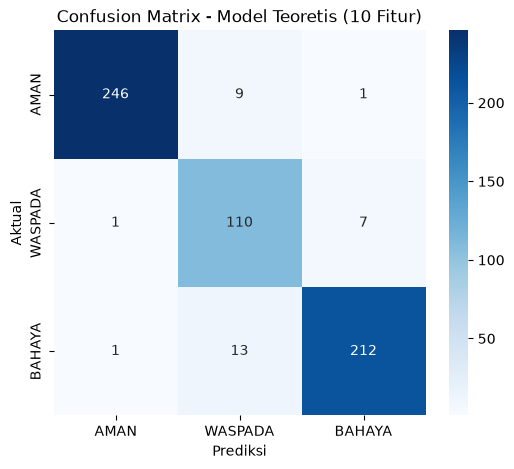

In [26]:
from sklearn.metrics import confusion_matrix

y_pred_th = np.argmax(model_theory.predict(X_te_th_sc), axis=1)
cm_th = confusion_matrix(y_te_th, y_pred_th)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_th, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["AMAN", "WASPADA", "BAHAYA"], 
            yticklabels=["AMAN", "WASPADA", "BAHAYA"])
plt.title('Confusion Matrix - Model Teoretis (10 Fitur)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')


---
## FASE 2: TRANSLASI SENSOR FISIK (Edge-AI IoT)

In [27]:
# ============================================================
# PEMILIHAN SUMBER DATA BERDASARKAN MODE
# ============================================================
df_all = pd.read_csv('siparta_sensor_dataset.csv')

if MODE == 'development':
    # Saat development, gunakan dummy ATAU iot (semuanya diperbolehkan)
    df_edge = df_all.copy()
    print(f"[DEV MODE] Menggunakan dataset kombinasi (Dummy + IoT): {len(df_edge)} baris.")
elif MODE == 'production':
    # Saat production, STRICTLY hanya data IoT aktual!
    df_edge = df_all[df_all['source'] == 'iot'].copy()
    print(f"[PROD MODE] Strict Data Policy Aktif. Hanya menggunakan data IoT aktual: {len(df_edge)} baris.")

# Validasi & Evaluasi
MIN_SAMPLES = 50
TRAINING_ALLOWED = len(df_edge) >= MIN_SAMPLES

if TRAINING_ALLOWED:
    FEATURE_EDGE = ['mics5524', 'tgs2600', 'mq2', 'mq135']
    X_e = df_edge[FEATURE_EDGE].values
    y_e = df_edge['label'].values
    
    # Check baseline (Majority Class) to prevent threshold memorization
    majority_class_acc = np.max(np.bincount(y_e)) / len(y_e)
    print(f"[EVAL] Baseline Accuracy (Majority Class): {majority_class_acc*100:.2f}%")
    
    X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_e, y_e, test_size=0.2, random_state=SEED, stratify=y_e)
    scaler_iot = StandardScaler()
    X_tr_e_sc = scaler_iot.fit_transform(X_tr_e)
    X_te_e_sc = scaler_iot.transform(X_te_e)
    
    model_edge = build_ann_model(4, 3, 'edge')
    print("[STATUS] Melatih Edge Model (Sensor Input)...")
    history_edge = model_edge.fit(X_tr_e_sc, to_categorical(y_tr_e, 3), validation_split=0.2, epochs=30, batch_size=32, verbose=0)
    
    y_pred = np.argmax(model_edge.predict(X_te_e_sc), axis=1)
    acc_e = accuracy_score(y_te_e, y_pred)
    print(f"✅ Akurasi Test Model Edge: {acc_e*100:.2f}%")
    
    if acc_e > majority_class_acc + 0.1:
        print("✅ [PASS] Model berhasil belajar pola (mengalahkan baseline).")
    else:
        print("⚠️ [WARNING] Model berpotensi underfitting atau gagal belajar melebihi baseline threshold.")
        
    # Simpan Artefak
    os.makedirs('model', exist_ok=True)
    with open('model/siparta_scaler.pkl', 'wb') as f:
        pickle.dump(scaler_iot, f)
    
    # Tambahkan metadata pada model untuk mencegah ketidaksinkronan
    converter = tf.lite.TFLiteConverter.from_keras_model(model_edge)
    with open('model/siparta_model.tflite', 'wb') as f:
        f.write(converter.convert())
    model_edge.save('model/siparta_ann.keras')
    model_edge.save('model/siparta_ann.h5')
    print("[SUCCESS] Model TFLite, H5, Keras & Scaler berhasil diexport.")
else:
    print(f"[STATUS] DATA_UNAVAILABLE: Sampel insufisien untuk Mode {MODE.upper()} ({len(df_edge)} < {MIN_SAMPLES}).")
    print("[SKIP] Pelatihan Edge AI dibatalkan demi menjaga integritas model.")

[DEV MODE] Menggunakan dataset kombinasi (Dummy + IoT): 3001 baris.
[EVAL] Baseline Accuracy (Majority Class): 42.62%
[STATUS] Melatih Edge Model (Sensor Input)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
✅ Akurasi Test Model Edge: 99.83%
✅ [PASS] Model berhasil belajar pola (mengalahkan baseline).
INFO:tensorflow:Assets written to: /tmp/tmpvcdkzgt3/assets


INFO:tensorflow:Assets written to: /tmp/tmpvcdkzgt3/assets


Saved artifact at '/tmp/tmpvcdkzgt3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_280')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140509256428112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256432144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256429648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256430992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256429840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256430416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256432720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256431184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256430800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256429456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140509256431568: Ten

W0000 00:00:1790972060.549204 1050544 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790972060.549214 1050544 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790972060.549312 1050544 reader.cc:83] Reading SavedModel from: /tmp/tmpvcdkzgt3
I0000 00:00:1790972060.549925 1050544 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790972060.549930 1050544 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpvcdkzgt3
I0000 00:00:1790972060.556821 1050544 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790972060.603954 1050544 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpvcdkzgt3
I0000 00:00:1790972060.620588 1050544 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 71288 microseconds.


[SUCCESS] Model TFLite, H5, Keras & Scaler berhasil diexport.


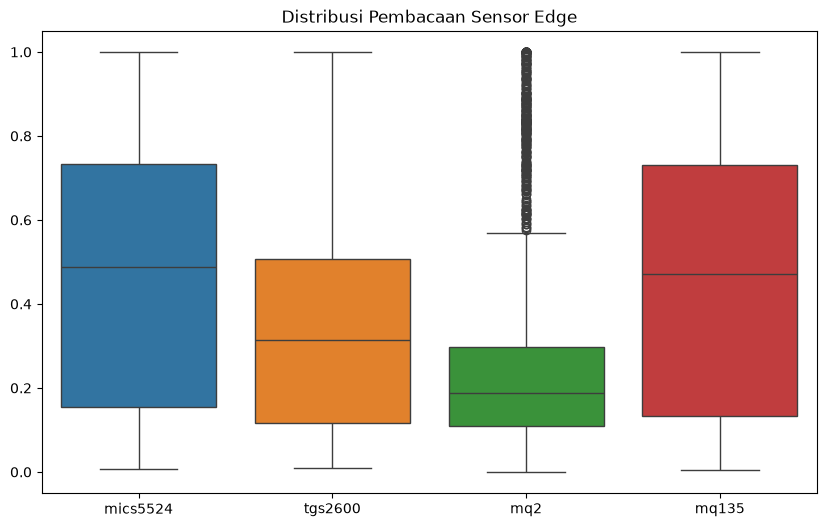

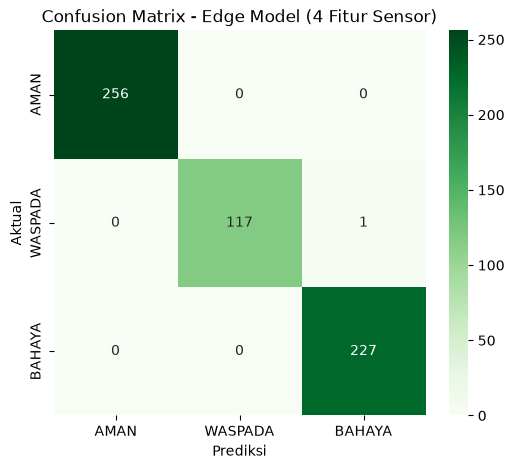

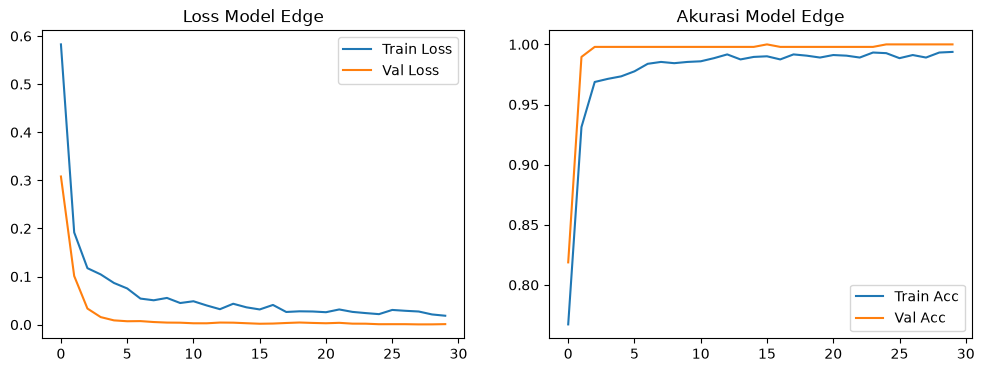

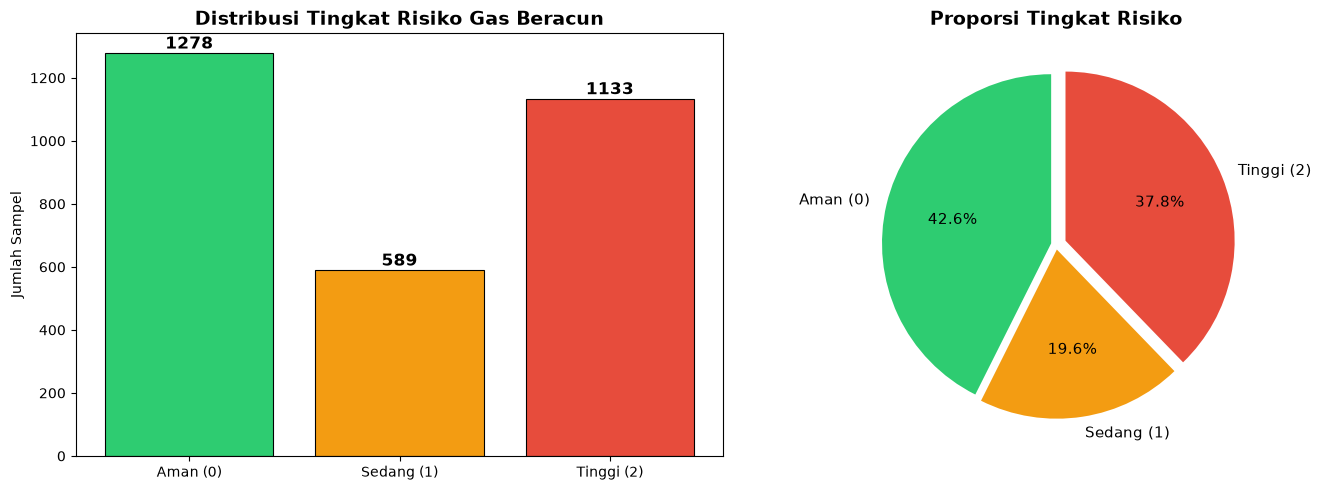

In [ ]:
if TRAINING_ALLOWED:
    # Distribusi Pembacaan Sensor
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_edge[['mics5524', 'tgs2600', 'mq2', 'mq135']])
    plt.title('Distribusi Pembacaan Sensor Edge')
    plt.show()
    
    # Confusion Matrix
    cm_e = confusion_matrix(y_te_e, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_e, annot=True, fmt='d', cmap='Greens', 
                xticklabels=["AMAN", "WASPADA", "BAHAYA"], 
                yticklabels=["AMAN", "WASPADA", "BAHAYA"])
    plt.title('Confusion Matrix - Edge Model (4 Fitur Sensor)')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()
    
    # Loss dan Akurasi
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history_edge.history['loss'], label='Train Loss')
    ax[0].plot(history_edge.history['val_loss'], label='Val Loss')
    ax[0].set_title('Loss Model Edge')
    ax[0].legend()
    
    ax[1].plot(history_edge.history['accuracy'], label='Train Acc')
    ax[1].plot(history_edge.history['val_accuracy'], label='Val Acc')
    ax[1].set_title('Akurasi Model Edge')
    ax[1].legend()

    # ============================================================
    # Distribusi Tingkat Risiko
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    risk_counts = df['tingkat_risiko'].value_counts().sort_index()
    risk_labels = ['Aman (0)', 'Sedang (1)', 'Tinggi (2)']
    colors = ['#2ecc71', '#f39c12', '#e74c3c']

    bars = axes[0].bar(risk_labels, risk_counts.values, color=colors, edgecolor='black', linewidth=0.8)
    axes[0].set_title('Distribusi Tingkat Risiko Gas Beracun', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Jumlah Sampel')
    for bar, val in zip(bars, risk_counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, val + 15, str(val),
                    ha='center', fontweight='bold', fontsize=12)

    # Pie chart
    axes[1].pie(risk_counts.values, labels=risk_labels, autopct='%1.1f%%',
                colors=colors, startangle=90, explode=[0.03, 0.03, 0.06],
                textprops={'fontsize': 11})
    axes[1].set_title('Proporsi Tingkat Risiko', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ============================================================
    # Distribusi fitur numerik berdasarkan tingkat risiko
    # ============================================================
    fitur_numerik = ['pH_bahan_1', 'pH_bahan_2', 'delta_pH', 'konsentrasi_1',
                    'konsentrasi_2', 'suhu_ruangan', 'ventilasi', 'volume_campuran_ml']

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for i, col in enumerate(fitur_numerik):
        for risk_level, color in zip([0, 1, 2], colors):
            data = df[df['tingkat_risiko'] == risk_level][col]
            axes[i].hist(data, bins=25, alpha=0.6, color=color, label=f'Risiko {risk_level}',
                        edgecolor='black', linewidth=0.3)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].legend(fontsize=8)

    plt.suptitle('Distribusi Fitur per Tingkat Risiko', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Correlation Heatmap
    # ============================================================
    fitur_korelasi = fitur_numerik + ['bahan_1', 'bahan_2', 'tingkat_risiko']

    plt.figure(figsize=(12, 8))
    corr = df[fitur_korelasi].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5)
    plt.title('Correlation Heatmap - Dataset Gas Beracun', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [31]:
# ============================================================
# Informasi Dataset
# ============================================================
print("=" * 60)
print("INFORMASI DATASET SIPARTA")
print("=" * 60)
print(f"Jumlah sampel  : {df.shape[0]}")
print(f"Jumlah fitur   : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nStatistik deskriptif:")
df.describe()

INFORMASI DATASET SIPARTA
Jumlah sampel  : 3000
Jumlah fitur   : 12
Missing values : 0

Tipe data:
bahan_1                 int64
bahan_2                 int64
pH_bahan_1            float64
pH_bahan_2            float64
delta_pH              float64
konsentrasi_1         float64
konsentrasi_2         float64
suhu_ruangan          float64
ventilasi             float64
volume_campuran_ml    float64
tingkat_risiko          int64
source                    str
dtype: object

Statistik deskriptif:


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
count,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.134000,4.728333,8.81008,5.613067,4.832217,22.705270,48.287267,30.004600,0.504134,273.389100,0.951667
std,2.075929,2.240879,4.15082,2.832495,3.464902,33.408544,42.181940,5.795031,0.290842,129.620214,0.895320
min,0.000000,1.000000,0.28000,0.150000,0.000000,0.500000,0.500000,20.000000,0.000200,50.000000,0.000000
25%,0.000000,3.000000,6.69000,2.570000,1.170000,5.290000,10.135000,24.970000,0.247450,162.375000,0.000000
50%,2.000000,5.000000,11.24000,6.840000,4.920000,8.625000,16.305000,30.070000,0.506750,273.250000,1.000000
75%,4.000000,6.000000,12.34000,7.130000,6.502500,15.145000,98.882500,35.047500,0.754150,385.300000,2.000000
max,7.000000,10.000000,14.90000,12.240000,12.630000,105.840000,106.190000,40.000000,1.000000,499.800000,2.000000


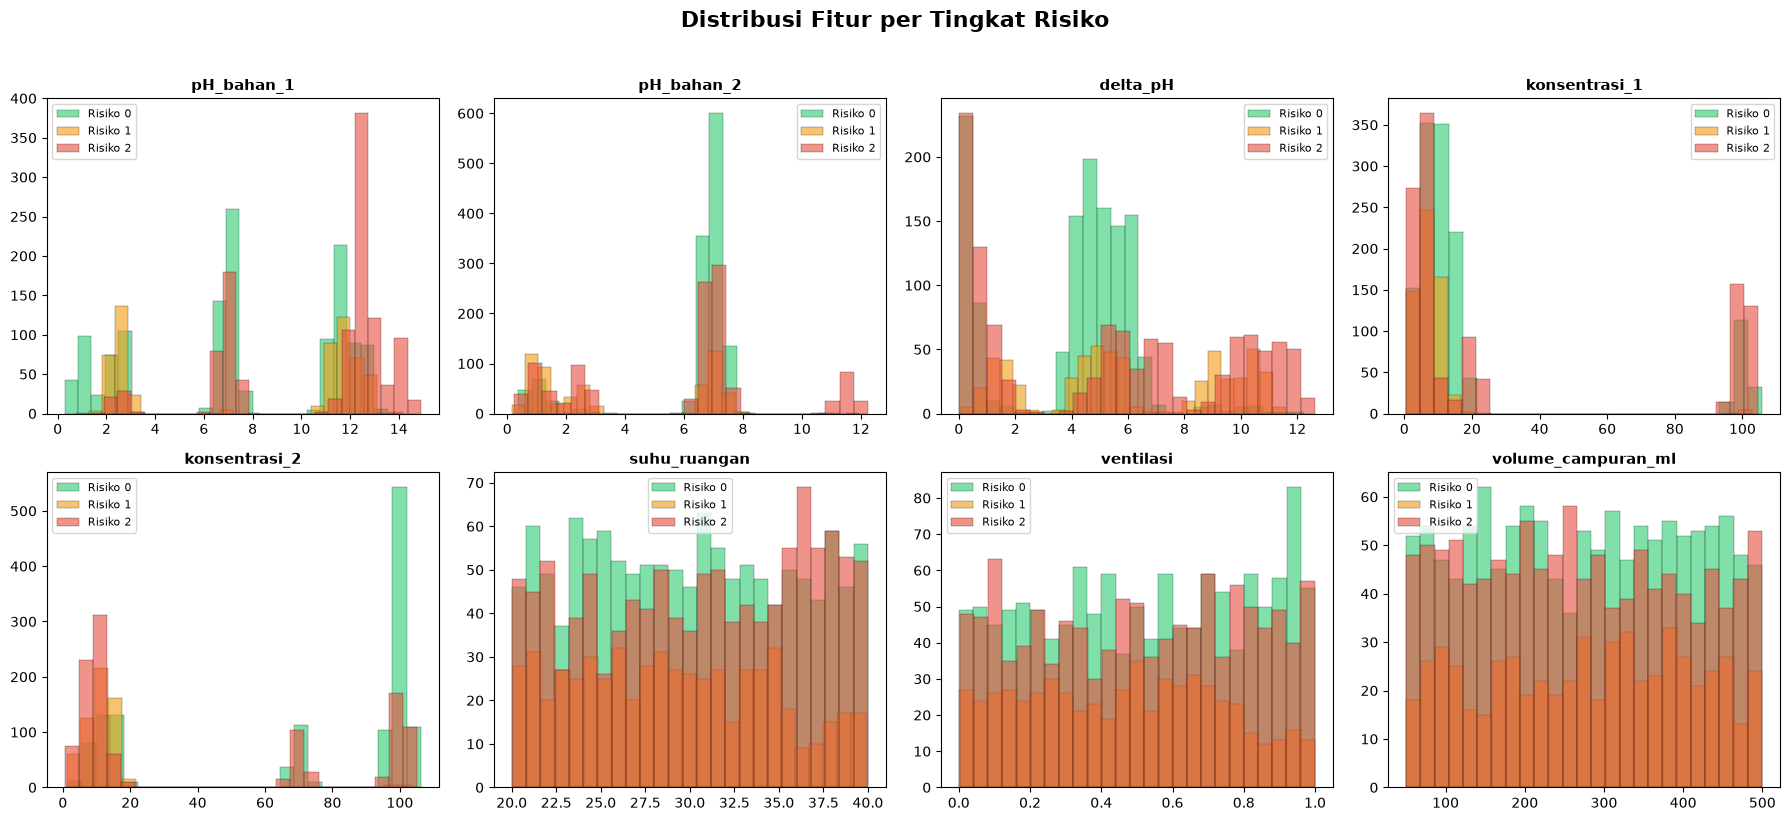

---
## FASE 3: SIMULASI INFERENCE (TFLite)
Memastikan struktur preprocessing antara hasil `scaler_iot` dengan file model TFLite sesuai.

In [29]:
class EdgeInferenceEngine:
    def __init__(self, tflite_path="model/siparta_model.tflite", scaler_path="model/siparta_scaler.pkl"):
        self.ready = False
        try:
            self.interpreter = tf.lite.Interpreter(model_path=tflite_path)
            self.interpreter.allocate_tensors()
            self.input_details = self.interpreter.get_input_details()
            self.output_details = self.interpreter.get_output_details()
            with open(scaler_path, 'rb') as f:
                self.scaler = pickle.load(f)
            self.ready = True
            print("[INFO] Engine Inference TFLite Ready.")
        except Exception as e:
            print(f"[WARNING] Engine Inference Offline: {e}")

    def predict(self, mics, tgs, mq2, mq135):
        if not self.ready: return "MODEL_ERROR"
        if mics == 0 and tgs == 0 and mq2 == 0 and mq135 == 0: return "DATA_UNAVAILABLE" # Simulasi perangkat terputus
            
        features = np.array([[mics, tgs, mq2, mq135]], dtype=np.float32)
        features_scaled = self.scaler.transform(features).astype(np.float32)
        
        self.interpreter.set_tensor(self.input_details[0]['index'], features_scaled)
        self.interpreter.invoke()
        output = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
        return ["AMAN", "WASPADA", "BAHAYA"][np.argmax(output)]

engine = EdgeInferenceEngine()
print(f"Simulasi Inferensi (Mics=0.8, TGS=0.4, MQ2=0.7, MQ135=0.2) -> {engine.predict(0.8, 0.4, 0.7, 0.2)}")


[INFO] Engine Inference TFLite Ready.
Simulasi Inferensi (Mics=0.8, TGS=0.4, MQ2=0.7, MQ135=0.2) -> AMAN


/home/brayone-xv/Documents/My File/CODE/lomba/pkm-kc/SIPARTA/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
